In [65]:
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties import unumpy as unp
import scipy

In [73]:
x = unp.uarray([1,2,3,4],1)


AttributeError: module 'uncertainties.unumpy' has no attribute 'average'

In [66]:
VZ_Masse = 444 # +- 1g
HZ_Masse = 443 # +- 1g
Messfehler = 0.05 # mm
HZ_Durchmesser_Außen = 50 # mm
HZ_Durchmesser_Innen = 40.6 
HZ_Wanddicke = 4.7

HZ_Durchmesser_Au0en = 50.05



In [67]:
Unterkannte_Platte_oben = 0.149
Tisch_Distanz_Platte = 0.988



In [68]:
Unsicherheit_Abstandsmessung = 0.001
Abstände_Lichtschranken = unp.uarray([0, 9, 36.5, 82],0.001) / 100 # cm
Abstand_erste_Lichtschranke = 2.5 # cm

Unsicherheit_Zeitmessung = 0.0003 # 

# Wir fangen nicht beim realeasen an, weil Wir den systematischen fehler der lichtschranken nicht kennen und nicht wissen wann genau der timer startet (im vregleich zum losrollen) 8
# Skalenteilung 1 ms
HZ_Zeiten = np.array([
    [0.269,0.555,1.013,1.482],
    [0.254,0.542,1.002,1.471],
    [0.260,0.550,1.009,1.478],
    [0.256,0.547,1.008,1.477],
    [0.249,0.540,1.001,1.469]

])

VZ_Zeiten = np.array([
    [0.228,0.492,0.909,1.333],
    [0.227,0.490,0.907,1.330],
    [0.227,0.490,0.907,1.330],
    [0.239,0.499,0.912,1.335],
    [0.231,0.493,0.909,1.332]
    
])

HZ_t_squared = unp.uarray(HZ_Zeiten, Unsicherheit_Zeitmessung) ** 2
VZ_t_squared = unp.uarray(VZ_Zeiten, Unsicherheit_Zeitmessung) ** 2


In [69]:
def nom(x): return unp.nominal_values(x)

def std(x) : return unp.std_devs(x)

In [70]:
class UCurve:
    def __init__(self,inter, slope, d_inter, d_slope):
        self.inter = inter
        self.slope = slope
        self.d_inter = d_inter
        self.d_slope = d_slope

    def get_uinter(self):
        return ufloat(self.inter, self.d_inter)

    def get_uslope(self):
        return ufloat(self.slope, self.d_slope)

    def __repr__(self):
        return (f"Slope: {self.get_uslope()} Inter: {self.get_uinter()}")

    def fit(x_data, y_data, y_sigma):
        def linear_function(x, intercept, slope):
            return intercept + slope * x
        a_fit, cov = scipy.optimize.curve_fit(linear_function, x_data,y_data, sigma=y_sigma, absolute_sigma=True)
        return UCurve(a_fit[0],a_fit[1],np.sqrt(cov[0][0]),np.sqrt(cov[1][1]))
    def ufit(x_data, y_udata):
        return UCurve.fit(x_data,unp.nominal_values(y_udata), unp.std_devs(y_udata))

    def draw_avg_with_errorbars(self,x_data,y_udata, xlabel="", ylabel="", filename=""):
        plt.errorbar(x_data, unp.nominal_values(y_udata), unp.std_devs(y_udata), fmt="r.",markersize=2,label="Data")

        y_fit = self.inter + self.slope * x_data
        plt.plot(x_data,y_fit, label="fit")

        y_fit_e1 = self.inter - self.d_inter + (self.slope + self.d_slope) * x_data
        plt.plot(x_data, y_fit_e1, label = "Error", linestyle="dashed")     
        
        y_fit_e2 = self.inter + self.d_inter + (self.slope - self.d_slope) * x_data
        plt.plot(x_data, y_fit_e2, label = "Error", linestyle="dashed")

        plt.legend()
        
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if filename != "":
            plt.savefig(filename)
        else:
            plt.show()

def uarray_from_arrayu(au):
    values, stds = [], []
    for x in au:
        values.append(x.nominal_value)
        stds.append(x.std_dev)
    return unp.uarray(values,stds)




In [75]:
HZ_fits = []
for i in range(5):
    fit = UCurve.ufit(nom(HZ_t_squared[i]),Abstände_Lichtschranken)
    HZ_fits.append(fit.get_uslope())
HZ_fits

[0.3861353577069428+/-6.050288691147197e-06,
 0.39041150515028594+/-6.11726425923243e-06,
 0.3874311892729045+/-6.0705906703416645e-06,
 0.3874905984809582+/-6.071529009940179e-06,
 0.391062583276432+/-6.127484383555406e-06]

TypeError: can't convert an affine function (<class 'uncertainties.core.AffineScalarFunc'>) to float; use x.nominal_value

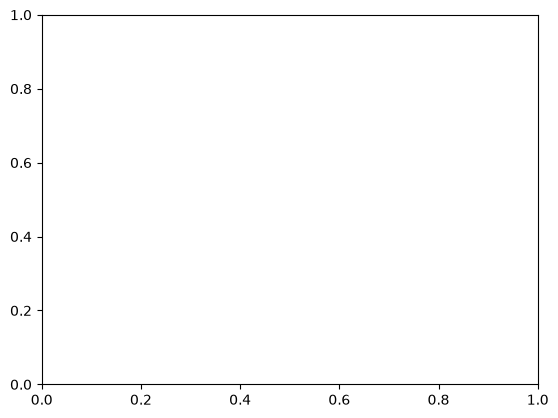

In [72]:
for i in range(5):
    t_squared = np.square(unp.uarray(HZ_Zeiten[i], [Unsicherheit_Zeitmessung] * 4))
    plt.errorbar(nom(t_squared),Abstände_Lichtschranken, xerr=std(t_squared),yerr=Unsicherheit_Abstandsmessung, fmt='.', color='black',
             ecolor='red', capsize=1)

for i in range(5):
    t_squared = np.square(unp.uarray(VZ_Zeiten[i], [Unsicherheit_Zeitmessung] * 4))
    plt.errorbar(nom(t_squared),Abstände_Lichtschranken, xerr=std(t_squared),yerr=Unsicherheit_Abstandsmessung, fmt=',', color='black',
             ecolor='red', capsize=1)


plt.xlabel("t^2 in s^2")
plt.ylabel("x in m")

# Energieerhaltung


In [ ]:
Rolldistanz = 87.3

D_Paar_1 = ufloat(0.0410,0.0001)
D_Paar_2 = ufloat(0.1490,0.0001)
# TODO Distanzen von Aaron abschreiben


In [ ]:

HZ_Zeiten_Geschwindigkeit = [
    [1.442,1.480,1.551,1.681],
    [1.449,1.187,1.558,1.689],
    [1.441,1.479,1.550,1.680],
    [1.443,1.481,1.553,1.684],
    [1.446,1.484,1.557,1.687]
]

VZ_Zeiten_Geschwindigkeit = [
    [1.310,1.344,1.409,1.528],
    [1.314,1.348,1.413,1.533],
    [1.314,1.349,1.414,1.536],
    [1.315,1.350,1.416,1.534],
    [1.309,1.343,1.409,1.531],
]


In [ ]:
# Geschwindigkeiten Ausrechnen
HZ_Geschwindigkeiten = []
for i in range(5):
    HZ_Geschwindigkeiten.append([D_Paar_1 / (ufloat(HZ_Zeiten_Geschwindigkeit[i][0],0.001) - ufloat(HZ_Zeiten_Geschwindigkeit[i][2],0.001)),D_Paar_2 / (ufloat(HZ_Zeiten_Geschwindigkeit[i][0],0.001) - ufloat(HZ_Zeiten_Geschwindigkeit[i][3],0.001))])

VZ_Geschwindigkeiten = []
for i in range(5):
    VZ_Geschwindigkeiten.append([D_Paar_1 / (ufloat(VZ_Zeiten_Geschwindigkeit[i][0],0.001) - ufloat(VZ_Zeiten_Geschwindigkeit[i][2],0.001)),D_Paar_2 / (ufloat(VZ_Zeiten_Geschwindigkeit[i][0],0.001) - ufloat(VZ_Zeiten_Geschwindigkeit[i][3],0.001))])
